In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex
from math import sqrt, pi

In [2]:
simulator = AerSimulator()

In [3]:
qc=QuantumCircuit(1)
qc.x(0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
print(result.get_statevector())

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


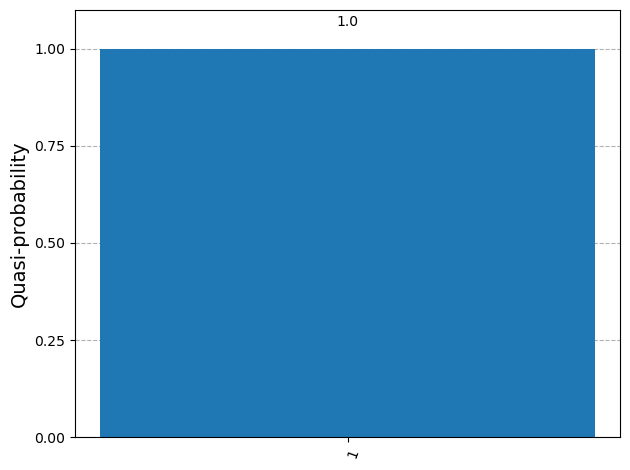

In [4]:
qc=QuantumCircuit(1)
qc.x(0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
plot_histogram(result.get_counts(0))

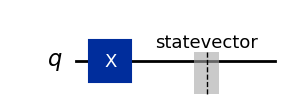

In [5]:
qcc.draw('mpl')

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


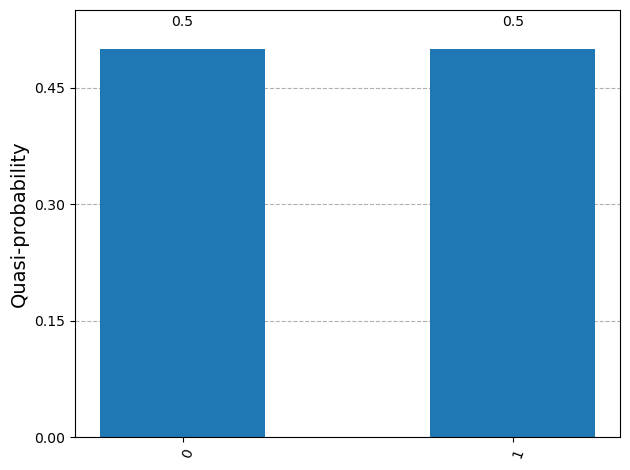

In [6]:
qc=QuantumCircuit(1)
qc.h(0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
print(result.get_statevector())
plot_histogram(result.get_counts(0))

In [7]:
qc=QuantumCircuit(1)
qc.h(0)
qc.save_unitary()
simulator = AerSimulator(method='unitary')
qcc = transpile(qc,simulator)
job = simulator.run(qcc)
unitary=job.result().get_unitary()
array_to_latex(unitary, prefix="\\text{Circuit =}\n")

<IPython.core.display.Latex object>

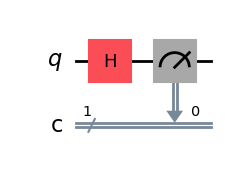

In [8]:
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure([0], [0])
qc.draw('mpl')

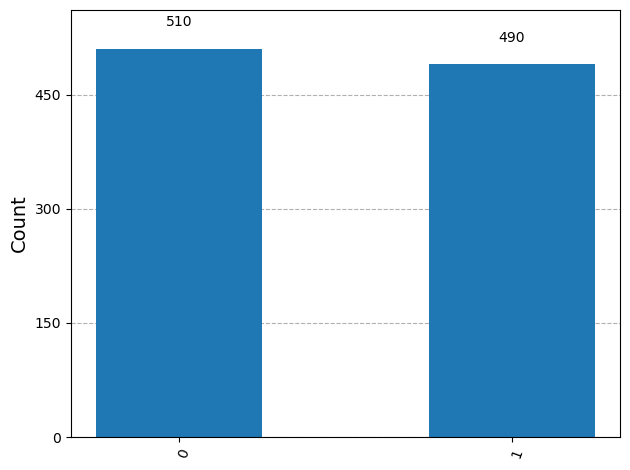

In [9]:
from qiskit_aer import QasmSimulator
simulator = QasmSimulator()
qcc = transpile(qc, simulator)
job = simulator.run(qcc,shots=1000)
plot_histogram(job.result().get_counts())

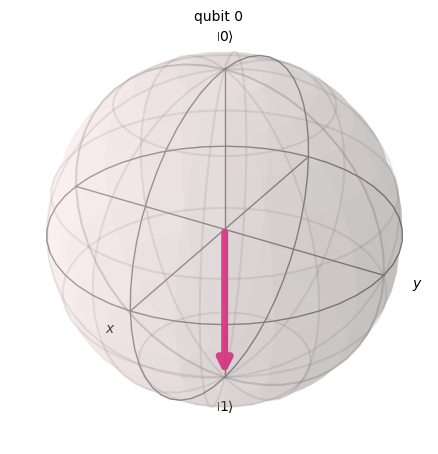

In [10]:
qc=QuantumCircuit(1)
qc.y(0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
plot_bloch_multivector(result.get_statevector())

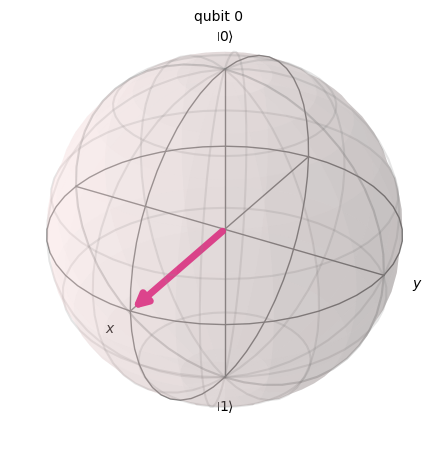

In [11]:
qc=QuantumCircuit(1)
qc.h(0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
plot_bloch_multivector(result.get_statevector())

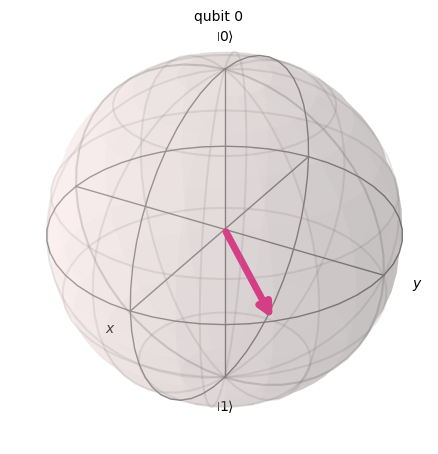

In [12]:
qc=QuantumCircuit(1)
qc.h(0)
qc.rz(pi/4,0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
plot_bloch_multivector(result.get_statevector())

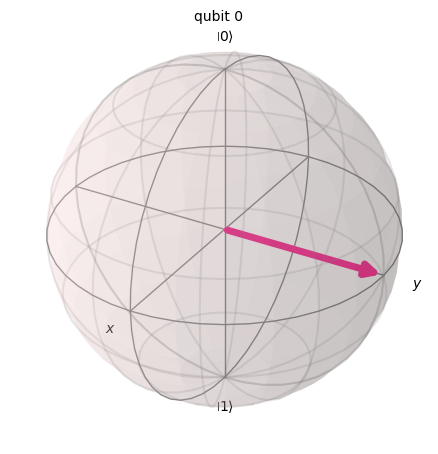

In [3]:
qc=QuantumCircuit(1)
qc.h(0)
qc.s(0)
qc.save_statevector()
#qc.draw('mpl')
simulator = AerSimulator(method='statevector')
qcc = transpile(qc, simulator)
result = simulator.run(qcc,shots=1024).result()
plot_bloch_multivector(result.get_statevector())

Before running the following cells make sure that you have installed ipywidgets.  You might get better interaction by selecting Render side-by-side from the View menu.  The interaction is a bit slow due to Qiskit.

In [5]:
import ipywidgets as widgets
from IPython.display import display

def rz(angle=pi/4):
    qc=QuantumCircuit(1)
    qc.h(0)
    qc.rz(angle,0)
    qc.save_statevector()
    simulator = AerSimulator(method='statevector')
    qcc = transpile(qc, simulator, optimization_level=0)
    result = simulator.run(qcc,shots=1).result()
    display(plot_bloch_multivector(result.get_statevector()))

#widgets.interactive(rz,angle=(0.0, 2*pi))
widgets.interactive(rz, angle=widgets.FloatSlider(min=0.0, max=2*pi, continuous_update=False))

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='angle', max=6.2831853071795…

In [7]:
gates= ["X", "Y", "Z", "H", "S", "T", "I", "Clear"]

q=QuantumCircuit(1)
q.save_statevector()

qc = QuantumCircuit(1)

def GateDemo(gate="X"):
    global qc
    match gate:
        case "X":
            qc.x(0)
        case "Y":
            qc.y(0)
        case "Z":
            qc.z(0)
        case "H":
            qc.h(0)
        case "S":
            qc.s(0)
        case "T":
            qc.t(0)
        case "Clear":
            qc = QuantumCircuit(1)
    qq=qc.compose(q)
    simulator = AerSimulator(method='statevector')
    qcc = transpile(qq, simulator, optimization_level=0)
    result = simulator.run(qcc,shots=1).result()
    display(plot_bloch_multivector(result.get_statevector()))

widgets.interactive(GateDemo, gate=widgets.RadioButtons(options=gates, orientation="vertical"))

interactive(children=(RadioButtons(description='gate', options=('X', 'Y', 'Z', 'H', 'S', 'T', 'I', 'Clear'), v…